##     Problem Statement
Despite having rich customer-level data, banks face challenges in: 
• Identifying high-risk customer segments 
• Understanding churn differences by geography and demographics 
• Quantifying the financial profile of churned customers 
Without structured analytics, churn management strategies remain generic, 
reactive, and inefficient 
# Project Objectives 
• Measure overall churn rate 
• Identify churn distribution across customer segments 
• Compare churn behavior across European regions 
# Secondary Objectives 
• Understand churn among high-value customers 
• Evaluate engagement and tenure patterns 
• Support strategic planning and marketing decisions 


##  Step1: Import Required Libraries

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Step2: Load Dataset

In [78]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.head())
print(df.info())

   Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Female   39       1   
4  2025    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  
<class 'pandas

## Step3: Data Cleaning

# Remove Unnecessary Column

In [79]:
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

# Check Null Values

In [80]:
print(df.isnull().sum())

Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## Step4: Create Segments

# Age Segment

In [81]:
bins = [18, 30, 45, 60, 100]
labels = ['<30', '30-45', '46-60', '60+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Credit Score Bands

In [82]:
def credit_band(score):
    if score < 500:
        return 'Low'
    elif score < 700:
        return 'Medium'
    else:
        return 'High'

df['CreditBand'] = df['CreditScore'].apply(credit_band)

# Tenure Groups

In [83]:
def tenure_group(t):
    if t <= 3:
        return 'New'
    elif t <= 7:
        return 'Mid-term'
    else:
        return 'Long-term'

df['TenureGroup'] = df['Tenure'].apply(tenure_group)

# Balance Segments

In [84]:
def balance_segment(balance):
    if balance == 0:
        return 'Zero Balance'
    elif balance < 100000:
        return 'Low Balance'
    else:
        return 'High Balance'

df['BalanceSegment'] = df['Balance'].apply(balance_segment)

In [85]:
df

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditBand,TenureGroup,BalanceSegment
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero Balance
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low Balance
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Medium,Long-term,High Balance
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero Balance
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High Balance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,771,France,Male,39,5,0.00,2,1,0,96270.64,0,30-45,High,Mid-term,Zero Balance
9996,2025,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,30-45,Medium,Long-term,Low Balance
9997,2025,709,France,Female,36,7,0.00,1,0,1,42085.58,1,30-45,High,Mid-term,Zero Balance
9998,2025,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,30-45,High,New,Low Balance


## Step5: Overall Churn Rate

In [86]:
overall_churn = df['Exited'].mean() * 100

print(f"Overall Churn Rate: {overall_churn:.2f}%")

Overall Churn Rate: 20.37%


## Step6: Segment-wise Churn

# Geography

In [87]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100

print(geo_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


# Gender

In [88]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
print (gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


# Age Group

In [89]:
age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100
print (age_churn)

AgeGroup
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64


##  Step7:  High Value Customer Churn

# Define premium customers:

In [90]:
premium = df[df['Balance'] > 100000]

premium_churn = premium['Exited'].mean() * 100

print(premium_churn)

25.234423838299648


# Active vs Inactive Members

In [91]:
activity_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100

print(activity_churn)
#This usually becomes one of the strongest insights.

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


## Step8: Visualization Examples

# Geography-wise Churn

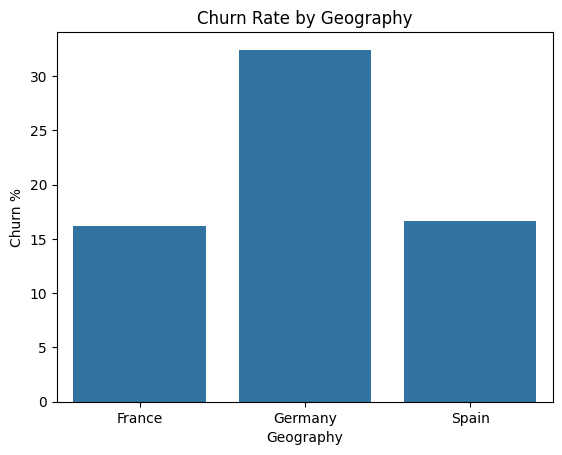

In [92]:
sns.barplot(x=geo_churn.index, y=geo_churn.values)

plt.title("Churn Rate by Geography")
plt.ylabel("Churn %")
plt.show()

# Age Group Churn

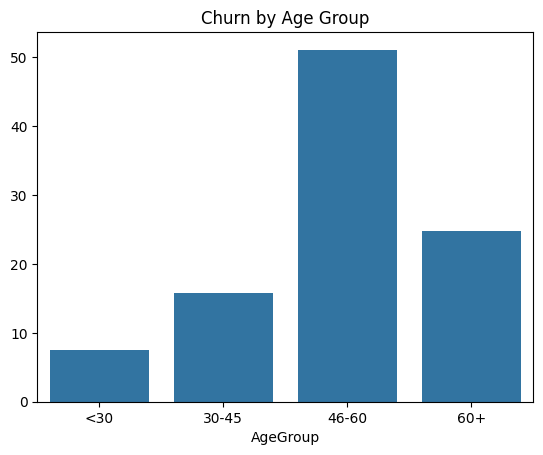

In [93]:
sns.barplot(x=age_churn.index, y=age_churn.values)

plt.title("Churn by Age Group")
plt.show()


**Key Insights**
- Germany usually has highest churn
- Older customers churn more
- Inactive members churn significantly more
- Customers with high balances are risky if disengaged
- Female churn may be slightly higher
- Customers with fewer products churn more

## Step9: Streamlit App Code
The cell below writes the Streamlit application to disk.

In [94]:
from pathlib import Path

app_code = r"""
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ---------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------
st.set_page_config(
    page_title="Customer Churn Intelligence Dashboard",
    page_icon="chart",
    layout="wide"
)

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("Churn_Modelling.csv")

    # Drop unnecessary columns
    drop_cols = ["RowNumber", "CustomerId", "Surname"]

    for col in drop_cols:
        if col in df.columns:
            df.drop(columns=col, inplace=True)

    return df


df = load_data()

# ---------------------------------------------------
# DATA PREPROCESSING
# ---------------------------------------------------

# Age Group
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)

# Balance Segment
df["BalanceSegment"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 100000, 300000],
    labels=["Zero Balance", "Medium Balance", "High Balance"]
)

# Tenure Group
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1, 3, 7, 10],
    labels=["New", "Mid-Term", "Loyal"]
)

# Churn Label
df["ChurnStatus"] = df["Exited"].map({
    0: "Retained",
    1: "Churned"
})

# ---------------------------------------------------
# SIDEBAR FILTERS
# ---------------------------------------------------
st.sidebar.header("Customer Filters")

selected_geo = st.sidebar.multiselect(
    "Select Geography",
    options=df["Geography"].unique(),
    default=df["Geography"].unique()
)

selected_gender = st.sidebar.multiselect(
    "Select Gender",
    options=df["Gender"].unique(),
    default=df["Gender"].unique()
)

selected_age = st.sidebar.multiselect(
    "Select Age Group",
    options=df["AgeGroup"].dropna().unique(),
    default=df["AgeGroup"].dropna().unique()
)

selected_tenure = st.sidebar.multiselect(
    "Select Tenure Group",
    options=df["TenureGroup"].dropna().unique(),
    default=df["TenureGroup"].dropna().unique()
)

# ---------------------------------------------------
# FILTER DATA
# ---------------------------------------------------
filtered_df = df[
    (df["Geography"].isin(selected_geo)) &
    (df["Gender"].isin(selected_gender)) &
    (df["AgeGroup"].isin(selected_age)) &
    (df["TenureGroup"].isin(selected_tenure))
]

# ---------------------------------------------------
# DASHBOARD TITLE
# ---------------------------------------------------
st.title("Customer Segmentation & Churn Insights Dashboard")

st.markdown("This interactive dashboard provides customer churn insights, customer segmentation analysis,and high-value customer behavior tracking using Streamlit and Plotly.")

st.markdown("---")

# ---------------------------------------------------
# KPI SECTION
# ---------------------------------------------------
total_customers = filtered_df.shape[0]
total_churned = filtered_df["Exited"].sum()
churn_rate = round((total_churned / total_customers) * 100, 2)

avg_balance = round(filtered_df["Balance"].mean(), 2)
avg_salary = round(filtered_df["EstimatedSalary"].mean(), 2)

col1, col2, col3, col4, col5 = st.columns(5)

col1.metric("Total Customers", f"{total_customers:,}")
col2.metric("Churned Customers", f"{total_churned:,}")
col3.metric("Churn Rate", f"{churn_rate}%")
col4.metric("Avg Balance", f"${avg_balance:,.0f}")
col5.metric("Avg Salary", f"${avg_salary:,.0f}")

st.markdown("---")

# ---------------------------------------------------
# OVERALL CHURN SUMMARY
# ---------------------------------------------------
st.subheader("Overall Churn Summary")

col6, col7 = st.columns(2)

with col6:
    churn_dist = filtered_df["ChurnStatus"].value_counts().reset_index()
    churn_dist.columns = ["Status", "Count"]

    fig_pie = px.pie(
        churn_dist,
        names="Status",
        values="Count",
        hole=0.5,
        title="Customer Churn Distribution"
    )

    st.plotly_chart(fig_pie, use_container_width=True)

with col7:
    churn_geo = (
        filtered_df.groupby("Geography")["Exited"]
        .mean()
        .reset_index()
    )

    churn_geo["Exited"] = churn_geo["Exited"] * 100

    fig_geo = px.bar(
        churn_geo,
        x="Geography",
        y="Exited",
        text_auto=".2f",
        title="Geography-wise Churn Rate",
        labels={"Exited": "Churn Rate (%)"}
    )

    st.plotly_chart(fig_geo, use_container_width=True)

st.markdown("---")

# ---------------------------------------------------
# AGE & TENURE ANALYSIS
# ---------------------------------------------------
st.subheader("Age & Tenure Churn Comparison")

col8, col9 = st.columns(2)

with col8:
    fig_age = px.box(
        filtered_df,
        x="ChurnStatus",
        y="Age",
        color="ChurnStatus",
        title="Age Distribution by Churn Status"
    )

    st.plotly_chart(fig_age, use_container_width=True)

with col9:
    fig_tenure = px.box(
        filtered_df,
        x="ChurnStatus",
        y="Tenure",
        color="ChurnStatus",
        title="Tenure Distribution by Churn Status"
    )

    st.plotly_chart(fig_tenure, use_container_width=True)

st.markdown("---")

# ---------------------------------------------------
# HIGH VALUE CUSTOMER EXPLORER
# ---------------------------------------------------
st.subheader("High-Value Customer Churn Explorer")

balance_threshold = st.slider(
    "Select Minimum Balance",
    min_value=0,
    max_value=int(df["Balance"].max()),
    value=100000
)

# Filter high-value customers
high_value_df = filtered_df[
    filtered_df["Balance"] >= balance_threshold
]

# BOX PLOT
fig_box = px.box(
    high_value_df,
    x="ChurnStatus",
    y="Balance",
    color="ChurnStatus",
    points="all",   # shows all data points
    hover_data=["Geography", "Gender", "Age"],
    title="Balance Distribution by Churn Status"
)

fig_box.update_layout(
    xaxis_title="Customer Status",
    yaxis_title="Balance",
    template="plotly_white"
)

st.plotly_chart(fig_box, use_container_width=True)

st.markdown("---")

# ---------------------------------------------------
# CUSTOMER SEGMENT ANALYSIS
# ---------------------------------------------------
st.subheader("Customer Segment Analysis")

# Calculate churn percentage by age group
segment_churn = (
    filtered_df.groupby("AgeGroup")["Exited"]
    .mean()
    .reset_index()
)

# Convert to percentage
segment_churn["Exited"] = segment_churn["Exited"] * 100

# BAR CHART
fig_segment = px.bar(
    segment_churn,
    x="AgeGroup",
    y="Exited",
    color="Exited",
    text=segment_churn["Exited"].round(1),
    title="Churn Rate Across Age Groups",
    labels={"Exited": "Churn Rate (%)"}
)

# Styling
fig_segment.update_traces(
    textposition='outside'
)

fig_segment.update_layout(
    template="plotly_white",
    xaxis_title="Age Group",
    yaxis_title="Churn Rate (%)"
)

st.plotly_chart(fig_segment, use_container_width=True)

st.markdown("---")
# ---------------------------------------------------
# DRILL DOWN VIEW
# ---------------------------------------------------
st.subheader("Customer Drill-Down View")

selected_country = st.selectbox(
    "Select Geography",
    filtered_df["Geography"].unique()
)

drill_df = filtered_df[
    filtered_df["Geography"] == selected_country
]

st.dataframe(
    drill_df[
        [
            "CreditScore",
            "Geography",
            "Gender",
            "Age",
            "Tenure",
            "Balance",
            "NumOfProducts",
            "HasCrCard",
            "IsActiveMember",
            "EstimatedSalary",
            "ChurnStatus"
        ]
    ],
    use_container_width=True
)

# ---------------------------------------------------
# DOWNLOAD SECTION
# ---------------------------------------------------
st.download_button(
    label="Download Filtered Data",
    data=filtered_df.to_csv(index=False),
    file_name="filtered_customer_data.csv",
    mime="text/csv"
)

# ---------------------------------------------------
# FOOTER
# ---------------------------------------------------
st.markdown("---")

st.caption(
    "Built with Streamlit | Plotly | Pandas | Machine Learning Analytics"
)

"""
Path("Customer_Segmentation_app.py").write_text(app_code)

print("Streamlit app created successfully!:" \
" Run `python -m streamlit run Customer_Segmentation_app.py` to launch the dashboard.")

Streamlit app created successfully!: Run `python -m streamlit run Customer_Segmentation_app.py` to launch the dashboard.


# Creating requirements.txt 

In [95]:
from pathlib import Path

requirements = """
streamlit==1.37.1
pandas==2.2.2
numpy==1.26.4
plotly==5.23.0
scikit-learn==1.5.1
matplotlib==3.9.1
seaborn==0.13.2
"""

Path(
    "requirements.txt"
).write_text(
    requirements,
    encoding="utf-8"
)

print("requirements.txt created successfully!")

requirements.txt created successfully!
